# Import and data loading

In [1]:
# =========================
# 1. IMPORT LIBRARIES
# =========================
import pandas as pd
import numpy as np
import ast

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

In [2]:
# =========================
# 2. LOAD DATA
# =========================

path = r"C:\Users\hp\Desktop\Major Pr\borg_traces_data.csv"

df = pd.read_csv(path)

print("Shape:", df.shape)
print(df.head())

Shape: (405894, 34)
   Unnamed: 0           time  instance_events_type  collection_id  \
0           0              0                     2    94591244395   
1           1  2517305308183                     2   260697606809   
2           2   195684022913                     6   276227177776   
3           3              0                     2    10507389885   
4           4  1810627494172                     3    25911621841   

   scheduling_class  collection_type  priority  alloc_collection_id  \
0                 3                1       200                    0   
1                 2                0       360         221495397286   
2                 2                0       103                    0   
3                 3                0       200                    0   
4                 2                0         0                    0   

   instance_index    machine_id  ... assigned_memory page_cache_memory  \
0             144  168846390496  ...        0.014435          0.

In [3]:
# =========================
# 3. DATA UNDERSTANDING
# =========================

print("\nColumns:\n", df.columns)

print("\nInfo:")
print(df.info())

print("\nMissing values:")
print(df.isna().sum())

print("\nStatistics:")
print(df.describe())


Columns:
 Index(['Unnamed: 0', 'time', 'instance_events_type', 'collection_id',
       'scheduling_class', 'collection_type', 'priority',
       'alloc_collection_id', 'instance_index', 'machine_id',
       'resource_request', 'constraint', 'collections_events_type', 'user',
       'collection_name', 'collection_logical_name',
       'start_after_collection_ids', 'vertical_scaling', 'scheduler',
       'start_time', 'end_time', 'average_usage', 'maximum_usage',
       'random_sample_usage', 'assigned_memory', 'page_cache_memory',
       'cycles_per_instruction', 'memory_accesses_per_instruction',
       'sample_rate', 'cpu_usage_distribution', 'tail_cpu_usage_distribution',
       'cluster', 'event', 'failed'],
      dtype='object')

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 405894 entries, 0 to 405893
Data columns (total 34 columns):
 #   Column                           Non-Null Count   Dtype  
---  ------                           --------------   -----  
 0   Unnamed

# Drop useless columns

In [4]:
# =========================
# 4. DROP USELESS COLUMNS
# =========================

drop_cols = [
    'Unnamed: 0',
    'constraint',
    'user',
    'collection_name',
    'collection_logical_name',
    'start_after_collection_ids',
    'cpu_usage_distribution',
    'tail_cpu_usage_distribution'
]

df.drop(columns=drop_cols, inplace=True, errors='ignore')

# Parse dictionary columns

In [5]:
#Parse dictionary columns
{'cpus': 0.02, 'memory': 0.01}

{'cpus': 0.02, 'memory': 0.01}

In [6]:
def extract_value(x, key):
    try:
        return ast.literal_eval(x)[key]
    except:
        return np.nan

In [7]:
#Apply Parsing
df['req_cpu'] = df['resource_request'].apply(lambda x: extract_value(x, 'cpus'))
df['req_mem'] = df['resource_request'].apply(lambda x: extract_value(x, 'memory'))

df['avg_cpu'] = df['average_usage'].apply(lambda x: extract_value(x, 'cpus'))
df['avg_mem'] = df['average_usage'].apply(lambda x: extract_value(x, 'memory'))

df['max_cpu'] = df['maximum_usage'].apply(lambda x: extract_value(x, 'cpus'))
df['max_mem'] = df['maximum_usage'].apply(lambda x: extract_value(x, 'memory'))

In [8]:
df.drop(columns=[
    'resource_request',
    'average_usage',
    'maximum_usage',
    'random_sample_usage'
], inplace=True)

# Feature Engineering

In [9]:
# runtime
df['runtime'] = df['end_time'] - df['start_time']

# scheduling delay
df['delay'] = df['start_time'] - df['time']

# CPU efficiency
df['cpu_efficiency'] = df['avg_cpu'] / (df['req_cpu'] + 1e-6)

# Handle Missing Values

In [10]:
df.fillna({
    'vertical_scaling': 0,
    'scheduler': 0,
    'cycles_per_instruction': df['cycles_per_instruction'].median(),
    'memory_accesses_per_instruction': df['memory_accesses_per_instruction'].median()
}, inplace=True)

df.fillna(0, inplace=True)


"""stats:

vertical_scaling → 959 missing

scheduler → 959 missing

cycles_per_instruction → many missing

memory_accesses_per_instruction → many missing"""

'stats:\n\nvertical_scaling → 959 missing\n\nscheduler → 959 missing\n\ncycles_per_instruction → many missing\n\nmemory_accesses_per_instruction → many missing'

# Encode categorical column

In [11]:
df['event'] = df['event'].astype('category').cat.codes

# Keep only numeric columns

In [12]:
df = df.select_dtypes(include=[np.number])

print("After cleaning shape:", df.shape)

After cleaning shape: (405894, 31)


# Feature Selection

In [13]:
features = [
    'priority',
    'machine_id',
    'req_cpu','req_mem',
    'avg_cpu','avg_mem',
    'max_cpu','max_mem',
    'assigned_memory',
    'page_cache_memory',
    'cycles_per_instruction',
    'memory_accesses_per_instruction',
    'runtime',
    'delay',
    'event',
    'failed'
]

df = df[features]

# Choose Target predict CPU usage

In [18]:
# =========================
# 5. DEFINE TARGET VARIABLES
# =========================

target_cols = ['req_cpu', 'req_mem', 'avg_cpu']

X = df.drop(columns=target_cols)
y = df[target_cols]

print("Input shape:", X.shape)
print("Output shape:", y.shape)

Input shape: (405894, 13)
Output shape: (405894, 3)


# Scaling

In [19]:
# =========================
# 6. SCALE FEATURES
# =========================

scaler = MinMaxScaler()

X_scaled = scaler.fit_transform(X)

# Train Test Split 

In [20]:
# =========================
# 7. TRAIN TEST SPLIT
# =========================

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (324715, 13)
Test: (81179, 13)


# Save clean dataset

In [17]:
clean_df = pd.concat([pd.DataFrame(X_scaled), y.reset_index(drop=True)], axis=1)

clean_df.to_csv("clean_borg_data.csv", index=False)
print("Clean data saved!")

Clean data saved!


# Applying Models

# MODEL 1 — ANN (Basic Neural Network)

In [22]:
# =========================
# 8. MLP MODEL
# =========================

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

mlp = Sequential()

mlp.add(Dense(128, activation='relu', input_shape=(X_train.shape[1],)))
mlp.add(Dense(64, activation='relu'))
mlp.add(Dense(32, activation='relu'))

# 3 outputs (CPU, memory, bandwidth)
mlp.add(Dense(3))

mlp.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

history = mlp.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=512,
    validation_split=0.2
)
# =========================
# 9. MODEL EVALUATION
# =========================

loss, mae = mlp.evaluate(X_test, y_test)

print("Test MAE:", mae)

# =========================
# 10. PREDICTIONS
# =========================

y_pred = mlp.predict(X_test)

pred_df = pd.DataFrame(
    y_pred,
    columns=["pred_cpu","pred_memory","pred_bandwidth"]
)

print(pred_df.head())

Epoch 1/20


C:\Users\hp\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\core\dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


508/508 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 3.9909e-04 - mae: 0.0102 - val_loss: 1.1010e-04 - val_mae: 0.0049
Epoch 2/20
508/508 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 1.1406e-04 - mae: 0.0051 - val_loss: 9.6759e-05 - val_mae: 0.0051
Epoch 3/20
508/508 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 9.8440e-05 - mae: 0.0047 - val_loss: 8.9053e-05 - val_mae: 0.0048
Epoch 4/20
508/508 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 8.6930e-05 - mae: 0.0046 - val_loss: 7.5411e-05 - val_mae: 0.0046
Epoch 5/20
508/508 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 7.7256e-05 - mae: 0.0043 - val_loss: 7.1420e-05 - val_mae: 0.0041
Epoch 6/20
508/508 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 7.2340e-05 - mae: 0.0041 - val_loss: 7.3692e-05 - val_mae: 0.0042
Epoch 7/20
508/508 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 6.9594e-05 - mae: 0.0040 - val_loss: 6.7161e-05 - val_mae: 0.0040
Epoch 8/20
508/508 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 6.5738e-05 - mae: 0.0039 - val_loss: 8.1688e-05 - val_mae: 0.0049
Epo

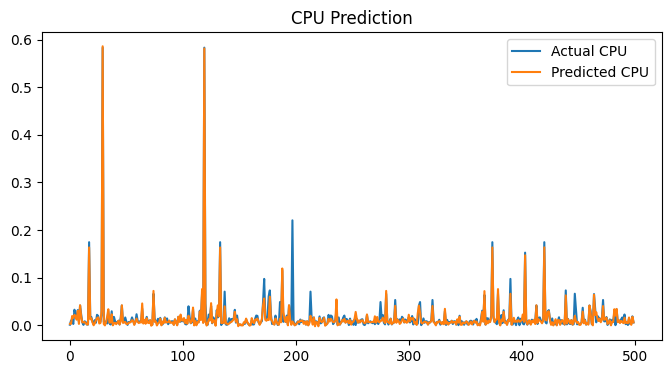

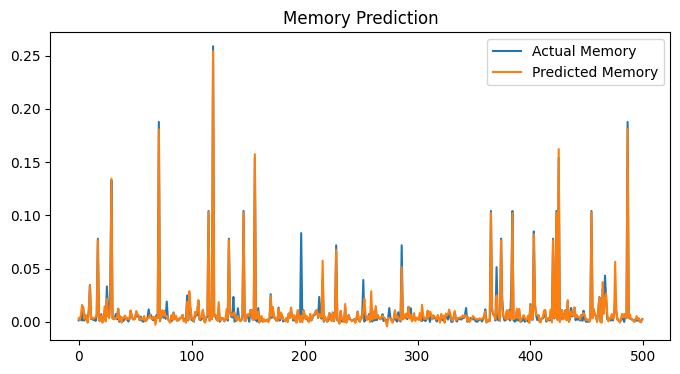

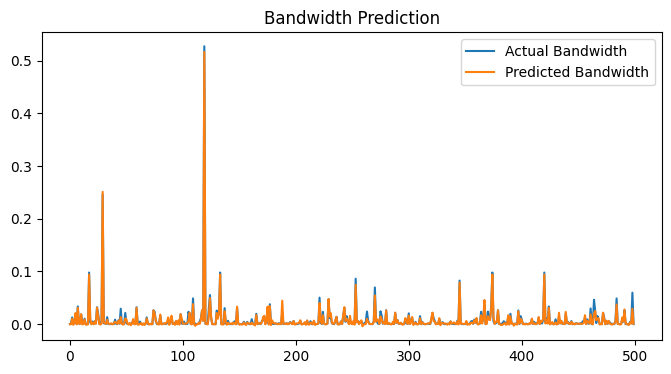

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))

plt.plot(y_test['req_cpu'].values[:500], label="Actual CPU")
plt.plot(y_pred[:500,0], label="Predicted CPU")

plt.legend()
plt.title("CPU Prediction")
plt.show()

plt.figure(figsize=(8,4))

plt.plot(y_test['req_mem'].values[:500], label="Actual Memory")
plt.plot(y_pred[:500,1], label="Predicted Memory")

plt.legend()
plt.title("Memory Prediction")
plt.show()

plt.figure(figsize=(8,4))

plt.plot(y_test['avg_cpu'].values[:500], label="Actual Bandwidth")
plt.plot(y_pred[:500,2], label="Predicted Bandwidth")

plt.legend()
plt.title("Bandwidth Prediction")
plt.show()

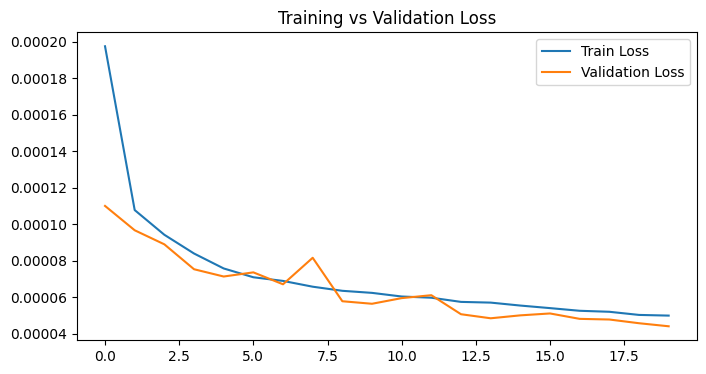

In [24]:
plt.figure(figsize=(8,4))

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.legend()
plt.title("Training vs Validation Loss")
plt.show()

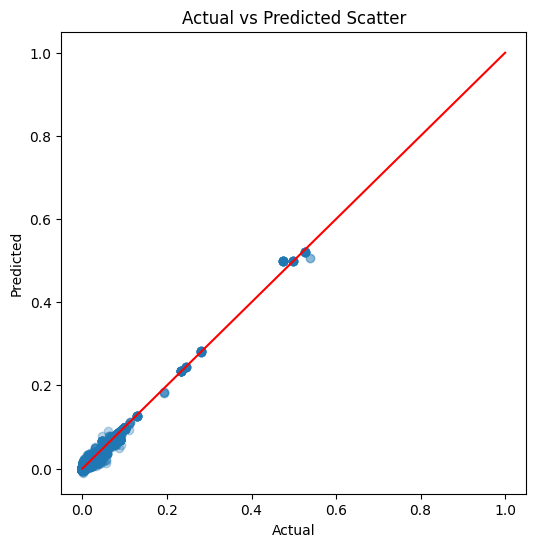

In [24]:
plt.figure(figsize=(6,6))

plt.scatter(y_true, y_pred, alpha=0.3)

plt.plot([0,1],[0,1], color='red')  # perfect line

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted Scatter")

plt.show()


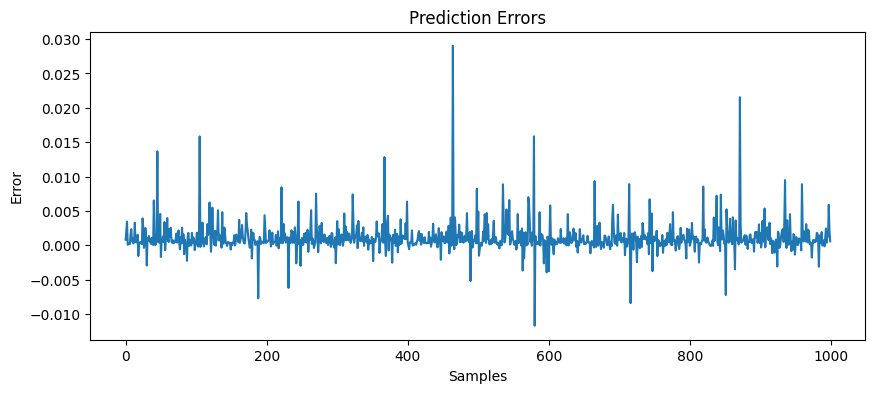

In [25]:
errors = y_true - y_pred

plt.figure(figsize=(10,4))
plt.plot(errors[:1000])
plt.title("Prediction Errors")
plt.xlabel("Samples")
plt.ylabel("Error")
plt.show()

In [26]:
history = ann.fit(
    X_train, y_train,
    epochs=20,
    batch_size=512,
    validation_split=0.2
)

Epoch 1/20
508/508 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4.7245e-06 - mae: 0.0012 - val_loss: 4.3672e-06 - val_mae: 9.9490e-04
Epoch 2/20
508/508 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4.2998e-06 - mae: 0.0011 - val_loss: 4.4538e-06 - val_mae: 0.0010
Epoch 3/20
508/508 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4.1790e-06 - mae: 0.0011 - val_loss: 5.5383e-06 - val_mae: 0.0013
Epoch 4/20
508/508 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 5.0273e-06 - mae: 0.0013 - val_loss: 4.2047e-06 - val_mae: 9.4729e-04
Epoch 5/20
508/508 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 3.8627e-06 - mae: 0.0010 - val_loss: 4.4523e-06 - val_mae: 0.0011
Epoch 6/20
508/508 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 3.9462e-06 - mae: 0.0011 - val_loss: 5.2210e-06 - val_mae: 0.0012
Epoch 7/20
508/508 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 3.6505e-06 - mae: 0.0010 - val_loss: 6.0198e-06 - val_mae: 0.0013
Epoch 8/20
508/508 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4.0975e-06 - mae: 0.0011 - val_loss: 4.2155e-06 - 

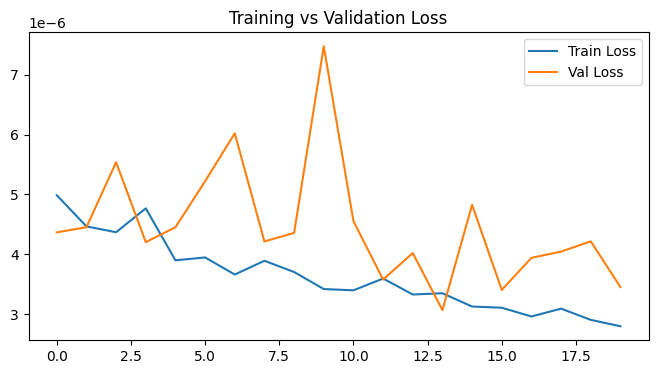

In [27]:
plt.figure(figsize=(8,4))

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')

plt.legend()
plt.title("Training vs Validation Loss")
plt.show()


In [28]:
from tensorflow.keras.callbacks import EarlyStopping

early = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = ann.fit(
    X_train, y_train,
    epochs=100,
    batch_size=512,
    validation_split=0.2,
    callbacks=[early]
)

Epoch 1/100
508/508 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 3.3732e-06 - mae: 9.4589e-04 - val_loss: 4.2218e-06 - val_mae: 9.4213e-04
Epoch 2/100
508/508 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 2.7180e-06 - mae: 8.6988e-04 - val_loss: 3.0938e-06 - val_mae: 7.8815e-04
Epoch 3/100
508/508 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 2.8930e-06 - mae: 9.0333e-04 - val_loss: 4.0256e-06 - val_mae: 8.6954e-04
Epoch 4/100
508/508 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 2.5436e-06 - mae: 8.4594e-04 - val_loss: 3.6556e-06 - val_mae: 0.0010
Epoch 5/100
508/508 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 2.8247e-06 - mae: 8.9576e-04 - val_loss: 3.8550e-06 - val_mae: 9.9544e-04
Epoch 6/100
508/508 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 2.5793e-06 - mae: 8.6714e-04 - val_loss: 3.8046e-06 - val_mae: 9.5353e-04
Epoch 7/100
508/508 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 2.7709e-06 - mae: 8.8387e-04 - val_loss: 3.2075e-06 - val_mae: 7.5597e-04


In [29]:
min(history.history['val_mae'])

0.0007559710065834224

# RL DQN

In [35]:
!pip install gymnasium


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [36]:
import gymnasium as gym
from gymnasium import spaces

In [37]:
def compute_energy(utilization, p_idle=100, p_max=200):
    return p_idle + (p_max - p_idle) * utilization

In [43]:
# Use original ANN feature columns
ann_feature_cols = [
    'priority',
    'machine_id',
    'req_cpu','req_mem',
    'avg_mem',
    'max_cpu','max_mem',
    'assigned_memory',
    'page_cache_memory',
    'cycles_per_instruction',
    'memory_accesses_per_instruction',
    'runtime',
    'delay',
    'event'
]

task_pool = df[ann_feature_cols].values

In [44]:
import gymnasium as gym
from gymnasium import spaces
import numpy as np

class SmartCloudEnv(gym.Env):

    def __init__(self, ann_model, scaler):
        super(SmartCloudEnv, self).__init__()

        self.ann_model = ann_model
        self.scaler = scaler

        self.vm_capacities = np.array([1.0, 0.8, 0.6])
        self.vm_cost = np.array([3.0, 2.0, 1.0])

        self.num_vms = len(self.vm_capacities)

        self.observation_space = spaces.Box(
            low=0, high=2,
            shape=(self.num_vms,),
            dtype=np.float32
        )

        self.action_space = spaces.Discrete(self.num_vms)

        self.max_steps = 200
        self.current_step = 0

    #  FIXED RESET
    def reset(self, seed=None, options=None):
        super().reset(seed=seed)

        self.vm_loads = np.zeros(self.num_vms, dtype=np.float32)
        self.current_step = 0

        return self.vm_loads, {}

    #  FIXED STEP
    def step(self, action):

        self.current_step += 1

        # Random fake task features (replace with real if needed)
        # pick random real task
        idx = np.random.randint(0, len(task_pool))
        task_features = task_pool[idx].reshape(1, -1)
        task_features = self.scaler.transform(task_features)
        task_features = self.scaler.transform(task_features)

        predicted_cpu = self.ann_model.predict(task_features, verbose=0)[0][0]
        predicted_cpu = np.clip(predicted_cpu, 0, 1)

        self.vm_loads[action] += predicted_cpu

        # SLA violation
        sla_violation = np.sum(self.vm_loads > self.vm_capacities)

        # Energy model
        def compute_energy(util, p_idle=100, p_max=200):
            return p_idle + (p_max - p_idle) * util

        energy = sum(
            compute_energy(
                min(self.vm_loads[i] / self.vm_capacities[i], 1)
            )
            for i in range(self.num_vms)
        )

        cost = sum(self.vm_loads[i] * self.vm_cost[i]
                   for i in range(self.num_vms))

        reward = (
            -10 * sla_violation
            -0.01 * energy
            -0.1 * cost
        )

        terminated = False
        truncated = self.current_step >= self.max_steps

        return self.vm_loads, reward, terminated, truncated, {}

In [45]:
from stable_baselines3 import DQN

env = SmartCloudEnv(model, scaler)

rl_model = DQN(
    "MlpPolicy",
    env,
    learning_rate=0.0005,
    buffer_size=10000,
    learning_starts=500,
    batch_size=32,
    verbose=1
)

rl_model.learn(total_timesteps=20000)

Using cuda device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


C:\Users\hp\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


ValueError: X has 14 features, but MinMaxScaler is expecting 15 features as input.

In [46]:
print("Scaler expects:", scaler.n_features_in_)

Scaler expects: 15


In [47]:
print("ANN input shape:", model.input_shape)

AttributeError: 'DQN' object has no attribute 'input_shape'